# Task 2 - Detection

## Import and setup

In [1]:
import os

import cv2
from IPython.display import display
import numpy as np
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import open3d as o3d
from PIL import Image
from scipy.spatial.transform import Rotation
from sympy import Matrix
from easydict import EasyDict as edict
from typing import Tuple

import tools.dataset_tools as dataset_tools
from tools.frame_pb2 import Frame
import tools.plot_tools as plot_tools
import torch
from tqdm.notebook import tqdm

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Process raw LiDAR point cloud data

In [2]:
frame = dataset_tools.read_frame("dataset/data_2/frame_0.pb")

# print number of lidars
print(f"Number of lidars: {len(frame.lidars)}")
lidar = frame.lidars[0]

# Extract pointcloud
pcl = dataset_tools.decode_lidar(lidar)
print(f"Pointcloud shape: {pcl.shape}")

Number of lidars: 1
Pointcloud shape: (196608, 4)


## Convert to Bird's Eye View representation

In [3]:
config = edict()
config.lims = edict()
config.lims.x = [-75, 75]
config.lims.y = [-75, 75]
config.lims.z = [-2, 5]
config.lims.intensity = [0, 0.4]
config.bev_height = 608
config.bev_width = 608

BEV shape: (3, 608, 608)


/home/lukas-kurz/Desktop/autonomous_driving/intro_to_autonomous_vehicles_2025/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


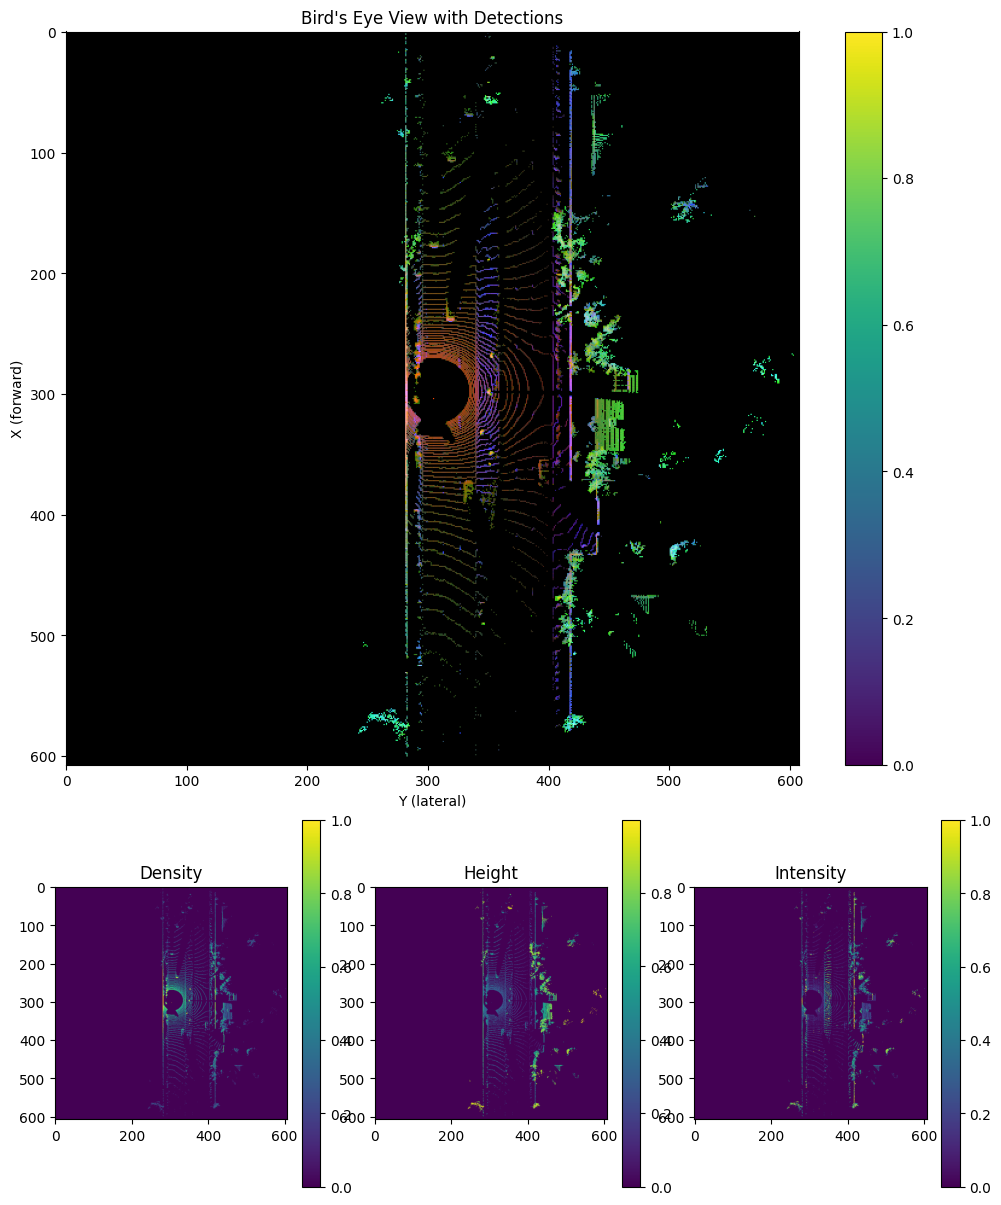

In [4]:
from tools.bev_tools import visualize_bev, pcl_to_bev

bev = pcl_to_bev(pcl, config)
print(f"BEV shape: {bev.shape}")

# Visualize BEV channels
visualize_bev(bev)

## Create Dataset

In [5]:
class LidarDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir: str):
        """
        Initialize the dataset
        Args:
            data_dir: path to dataset directory containing frame_*.pb files
            config: configuration dictionary with BEV parameters
        """
        self.data_dir = data_dir
        
        # Get list of all frame files
        self.frame_files = []
        for file in sorted(os.listdir(data_dir)):
            if file.startswith('frame_') and file.endswith('.pb'):
                self.frame_files.append(os.path.join(data_dir, file))
                
        print(f"Found {len(self.frame_files)} frames")
        
    def __len__(self):
        return len(self.frame_files)
    
    def __getitem__(self, idx):
        """
        Get a single frame data
        Args:
            idx: frame index
        Returns:
            pointcloud: (N, 4) array of points (x,y,z,intensity)
        """
        # Read frame
        frame = dataset_tools.read_frame(self.frame_files[idx])
        
        # Get first lidar's pointcloud
        lidar = frame.lidars[0]
        pointcloud = dataset_tools.decode_lidar(lidar)
        detections = lidar.detections
        bev = pcl_to_bev(pointcloud, config)
        
        # Convert numpy array to pytorch tensor
        bev = torch.from_numpy(bev).float()
        
        return bev, detections

# Create dataset
dataset = LidarDataset("dataset/data_2")

# Test loading first frame
bev, detections = dataset[0]
print(f"Loaded pointcloud shape: {bev.shape}")
print(f"Loaded {len(detections)} number of detections")
print(f"Detection 0: {detections[0]}")


Found 199 frames
Loaded pointcloud shape: torch.Size([3, 608, 608])
Loaded 6 number of detections
Detection 0: id: "8EFRSwEXBf9P-SzIDRzx0A"
pos: -20.02004
pos: 7.2557716
pos: 0.50248885
rot: 0.0
rot: 0.0
rot: -0.009081202
scale: 4.7602353
scale: 1.9828961
scale: 1.68



## Feed into deep learning model to detect vehicles

In [6]:
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### Define Model

In [45]:
from SFA3D.sfa.models.model_utils import create_model

# from the demo config of SFA3D

model_config = edict({
    "saved_fn": "fpn_resnet_18", # the name using for saving logs, models,...
    "arch": "fpn_resnet_18", # The name of the model architecture
    "pretrained_path": "SFA3D/checkpoints/fpn_resnet_18/fpn_resnet_18_epoch_300.pth",
    "K": 50, # the number of top K
    "no_cuda": False, #If true, cuda is not used.
    "gpu_idx": 0, #The index of the GPU to use.
    "num_samples": None,
    "num_workers": 1,
    "batch_size": 1,
    "peak_thresh": 0.1,
    "save_test_output": False,
    "output_format": "image",
    "output_video_fn": "out_fpn_resnet_18",
    "output_width": config.bev_width,
})
model_config.pin_memory = True
model_config.distributed = False  # For testing on 1 GPU only

model_config.input_size = (config.bev_height , config.bev_width )
model_config.hm_size = (152, 152)
model_config.down_ratio = 4
model_config.max_objects = 20

model_config.imagenet_pretrained = True
model_config.head_conv = 64
model_config.num_classes = 3
model_config.num_center_offset = 2
model_config.num_z = 1
model_config.num_dim = 3
model_config.num_direction = 2  # sin, cos

model_config.heads = {
    'hm_cen': model_config.num_classes,
    'cen_offset': model_config.num_center_offset,
    'direction': model_config.num_direction,
    'z_coor': model_config.num_z,
    'dim': model_config.num_dim
}

model = create_model(model_config)
model.load_state_dict(torch.load(model_config.pretrained_path, map_location=device))
model = model.to(device)
model.eval();

using ResNet architecture with feature pyramid
=> loading pretrained model https://download.pytorch.org/models/resnet18-5c106cde.pth


In [50]:
from SFA3D.sfa.utils.evaluation_utils import decode

bev, detections = dataset[1]

# Add batch dimension
bev = bev.unsqueeze(0)  # Shape: [1, 3, 608, 608]
bev = bev.to(device)
outputs = model(bev)

# print dimensions of outputs
print(f"Outputs: {len(outputs)}")
print(f"hm_cen: {outputs['hm_cen'].size()}") # [1, 3, 152, 152] -> 3 classes
print(f"cen_offset: {outputs['cen_offset'].size()}") # [1, 2, 152, 152] -> 2 offset values
print(f"direction: {outputs['direction'].size()}") # [1, 2, 152, 152] -> 2 direction values
print(f"z_coor: {outputs['z_coor'].size()}") # [1, 1, 152, 152] -> 1 z coordinate
print(f"dim: {outputs['dim'].size()}") # [1, 3, 152, 152] -> 3 dimensions

predicted_detections = decode(outputs['hm_cen'], outputs['cen_offset'], outputs['direction'], outputs['z_coor'], outputs['dim'], K=model_config.K)

print(f"Outputs: {len(outputs)}")
print(f"Predicted detections: {predicted_detections.size()}")

predicted_detections = predicted_detections[predicted_detections[:,:, 0] > 0.1]
print(f"Predicted detections: {predicted_detections.size()}")


torch.Size([3, 608, 608])
Outputs: 5
hm_cen: torch.Size([1, 3, 152, 152])
cen_offset: torch.Size([1, 2, 152, 152])
direction: torch.Size([1, 2, 152, 152])
z_coor: torch.Size([1, 1, 152, 152])
dim: torch.Size([1, 3, 152, 152])
Outputs: 5
Predicted detections: torch.Size([1, 50, 10])
Predicted detections: torch.Size([0, 10])


## Evaluate detection performance

In [48]:
from tools.lidar_tools import convert_predictions_to_lidar_format, convert_ground_truth_to_dict

# Convert both to comparable format
pred_detections = convert_predictions_to_lidar_format(predicted_detections)
gt_detections = convert_ground_truth_to_dict(detections)

# Example comparison
for pred, gt in zip(pred_detections[:5], gt_detections[:5]):  # First 5 for example
    print("Prediction:")
    print(f"- Position: {pred['pos']}")
    print(f"- Rotation: {pred['rot']}")
    print(f"- Scale: {pred['scale']}")
    print(f"- Type: {pred['type']}")
    print(f"- Confidence: {pred['confidence']}")
    print("\nGround Truth:")
    print(f"- Position: {gt['pos']}")
    print(f"- Rotation: {gt['rot']}")
    print(f"- Scale: {gt['scale']}")
    print(f"- Type: {gt['type']}")
    print("\n---")

In [10]:
import numpy as np
from typing import List, Dict

def calculate_iou_3d(box1: Dict, box2: Dict) -> float:
    """
    Calculate 3D IoU between two bounding boxes
    """
    # Convert center format to corners
    def get_box_corners(box):
        pos = np.array(box['pos'])
        scale = np.array(box['scale'])
        # Simplified IoU calculation using axis-aligned boxes
        min_corner = pos - scale/2
        max_corner = pos + scale/2
        return min_corner, max_corner
    
    min1, max1 = get_box_corners(box1)
    min2, max2 = get_box_corners(box2)
    
    # Calculate intersection
    intersection_min = np.maximum(min1, min2)
    intersection_max = np.minimum(max1, max2)
    
    if np.any(intersection_max < intersection_min):
        return 0.0
    
    intersection = np.prod(intersection_max - intersection_min)
    
    # Calculate volumes
    volume1 = np.prod(max1 - min1)
    volume2 = np.prod(max2 - min2)
    
    # Calculate IoU
    iou = intersection / (volume1 + volume2 - intersection)
    
    return float(iou)

def match_detections(predictions: List[Dict], ground_truth: List[Dict], iou_threshold: float = 0.5) -> List[tuple]:
    """
    Match predictions to ground truth based on IoU
    
    Args:
        predictions: List of predicted detections
        ground_truth: List of ground truth detections
        iou_threshold: Minimum IoU to consider a match
    
    Returns:
        List of (prediction, ground_truth) pairs
    """
    matches = []
    used_gt = set()
    
    # Sort predictions by confidence
    sorted_preds = sorted(predictions, key=lambda x: x['confidence'], reverse=True)
    
    for pred in sorted_preds:
        best_iou = iou_threshold
        best_gt = None
        
        # Find best matching ground truth for this prediction
        for i, gt in enumerate(ground_truth):
            if i in used_gt:
                continue
                
            iou = calculate_iou_3d(pred, gt)
            if iou > best_iou:
                best_iou = iou
                best_gt = gt
        
        # If we found a match, add it to our results
        if best_gt is not None:
            matches.append((pred, best_gt))
            used_gt.add(ground_truth.index(best_gt))
    
    return matches

def print_detection_comparison(matches: List[tuple]):
    """
    Print detailed comparison of matched detections
    """
    print(f"Found {len(matches)} matches\n")
    
    for i, (pred, gt) in enumerate(matches):
        print(f"Match {i+1}:")
        print("Prediction:")
        print(f"  Position: ({pred['pos'][0]:.2f}, {pred['pos'][1]:.2f}, {pred['pos'][2]:.2f})")
        print(f"  Scale: ({pred['scale'][0]:.2f}, {pred['scale'][1]:.2f}, {pred['scale'][2]:.2f})")
        print(f"  Type: {pred['type']}")
        print(f"  Confidence: {pred['confidence']:.3f}")
        
        print("Ground Truth:")
        print(f"  Position: ({gt['pos'][0]:.2f}, {gt['pos'][1]:.2f}, {gt['pos'][2]:.2f})")
        print(f"  Scale: ({gt['scale'][0]:.2f}, {gt['scale'][1]:.2f}, {gt['scale'][2]:.2f})")
        print(f"  Type: {gt['type']}")
        
        # Calculate position error
        pos_error = np.sqrt(sum((np.array(pred['pos']) - np.array(gt['pos']))**2))
        print(f"Position Error: {pos_error:.2f}m")
        
        # Calculate IoU
        iou = calculate_iou_3d(pred, gt)
        print(f"IoU: {iou:.3f}")
        print("-" * 50 + "\n")

# Usage example:
pred_detections = convert_predictions_to_lidar_format(predicted_detections)
gt_detections = convert_ground_truth_to_dict(detections)

# Match predictions with ground truth
matches = match_detections(pred_detections, gt_detections)

# Print detailed comparison
print_detection_comparison(matches)

# Calculate some summary statistics
total_gt = len(gt_detections)
total_pred = len(pred_detections)
total_matches = len(matches)

precision = total_matches / total_pred if total_pred > 0 else 0
recall = total_matches / total_gt if total_gt > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("Summary Statistics:")
print(f"Total Ground Truth: {total_gt}")
print(f"Total Predictions: {total_pred}")
print(f"Total Matches: {total_matches}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

Found 0 matches

Summary Statistics:
Total Ground Truth: 7
Total Predictions: 0
Total Matches: 0
Precision: 0.000
Recall: 0.000
F1 Score: 0.000


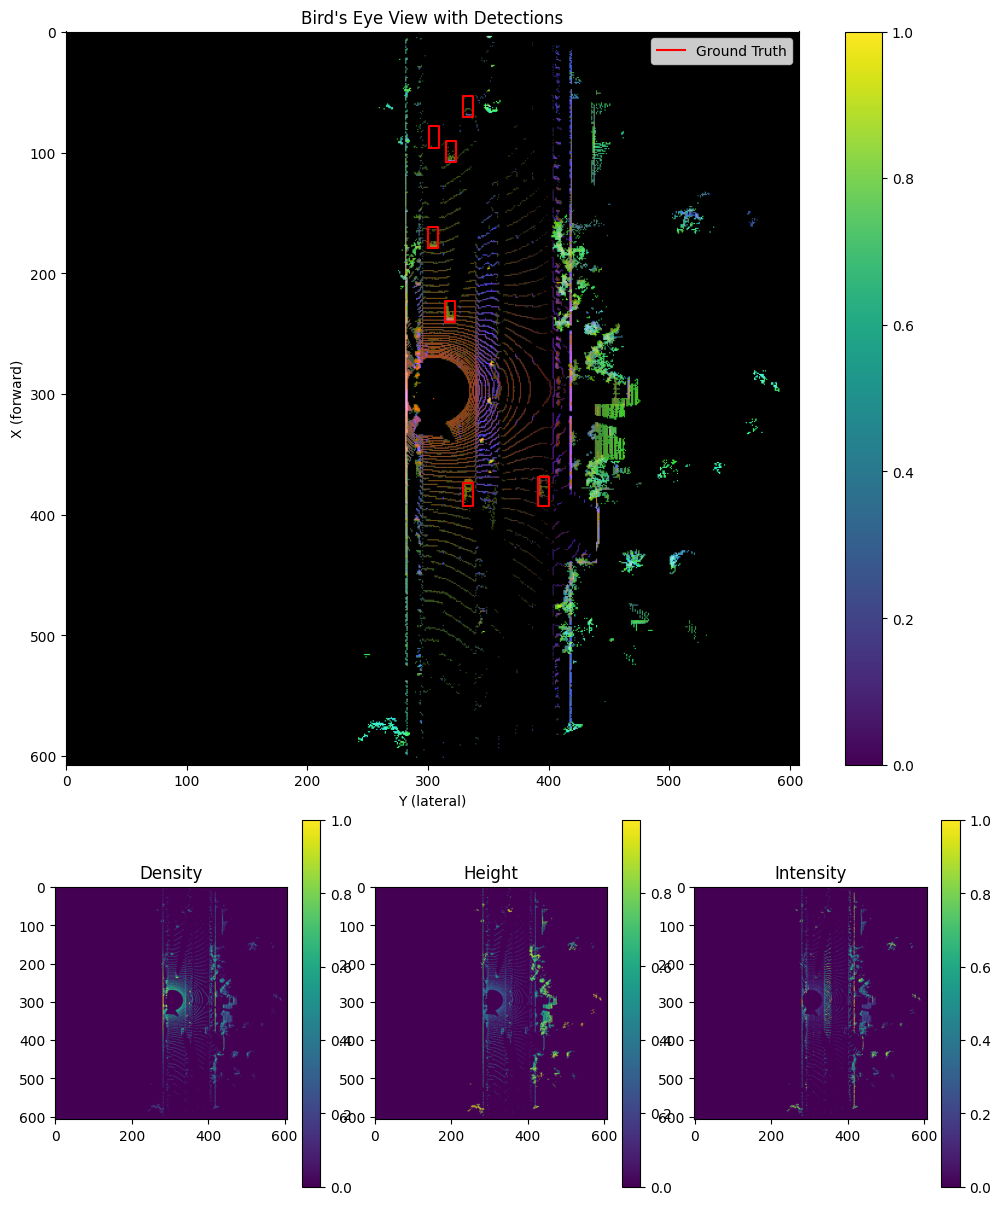

In [11]:
pred_detections = convert_predictions_to_lidar_format(predicted_detections)
gt_detections = convert_ground_truth_to_dict(detections)

# Visualize
visualize_bev(
    bev.cpu().numpy().squeeze(0),
    predictions=pred_detections,
    ground_truth=gt_detections,
    config=config  # Pass your config
)